In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df =  pd.read_csv("../weather_backend/weather_data.csv")
df

,city,date,time,temperature,air_quality_index
0,Hyderabad,2025-12-15,00:00,16.0,50
1,Hyderabad,2025-12-15,01:00,17.0,50
2,Hyderabad,2025-12-15,02:00,15.0,50
3,Hyderabad,2025-12-15,03:00,15.0,50
4,Hyderabad,2025-12-15,04:00,15.0,50
...,...,...,...,...,...
307,Hyderabad,2025-12-27,19:00,21.2,100
308,Hyderabad,2025-12-27,20:00,20.3,100
309,Hyderabad,2025-12-27,21:00,19.5,100
310,Hyderabad,2025-12-27,22:00,19.0,100


In [153]:
df.columns

Index(['city', 'date', 'time', 'temperature', 'air_quality_index', 'hour',
       'day', 'month', 'weekday'],
      dtype='object')

In [75]:
df.head()

,city,date,time,temperature,air_quality_index
0,Hyderabad,2025-12-15,00:00,16.0,50
1,Hyderabad,2025-12-15,01:00,17.0,50
2,Hyderabad,2025-12-15,02:00,15.0,50
3,Hyderabad,2025-12-15,03:00,15.0,50
4,Hyderabad,2025-12-15,04:00,15.0,50


In [76]:
df.tail()

,city,date,time,temperature,air_quality_index
307,Hyderabad,2025-12-27,19:00,21.2,100
308,Hyderabad,2025-12-27,20:00,20.3,100
309,Hyderabad,2025-12-27,21:00,19.5,100
310,Hyderabad,2025-12-27,22:00,19.0,100
311,Hyderabad,2025-12-27,23:00,18.6,100


In [77]:
df.dtypes

city                  object
date                  object
time                  object
temperature          float64
air_quality_index      int64
dtype: object

In [78]:
df["date"] = pd.to_datetime(df["date"])
df["time"] = pd.to_datetime(df["time"], format="%H:%M").dt.time

df.dtypes


city                         object
date                 datetime64[ns]
time                         object
temperature                 float64
air_quality_index             int64
dtype: object

In [79]:
type(df["time"].iloc[0])


datetime.time

In [80]:
df["hour"] = df["time"].apply(lambda x: x.hour)
df

,city,date,time,temperature,air_quality_index,hour
0,Hyderabad,2025-12-15,00:00:00,16.0,50,0
1,Hyderabad,2025-12-15,01:00:00,17.0,50,1
2,Hyderabad,2025-12-15,02:00:00,15.0,50,2
3,Hyderabad,2025-12-15,03:00:00,15.0,50,3
4,Hyderabad,2025-12-15,04:00:00,15.0,50,4
...,...,...,...,...,...,...
307,Hyderabad,2025-12-27,19:00:00,21.2,100,19
308,Hyderabad,2025-12-27,20:00:00,20.3,100,20
309,Hyderabad,2025-12-27,21:00:00,19.5,100,21
310,Hyderabad,2025-12-27,22:00:00,19.0,100,22


In [81]:
df.dtypes

city                         object
date                 datetime64[ns]
time                         object
temperature                 float64
air_quality_index             int64
hour                          int64
dtype: object

In [82]:
df.describe()

,date,temperature,air_quality_index,hour
count,312,312.000000,312.000000,312.000000
mean,2025-12-21 00:00:00,19.680449,82.051282,11.500000
min,2025-12-15 00:00:00,10.000000,50.000000,0.000000
25%,2025-12-18 00:00:00,15.500000,50.000000,5.750000
50%,2025-12-21 00:00:00,19.000000,100.000000,11.500000
75%,2025-12-24 00:00:00,24.700000,100.000000,17.250000
max,2025-12-27 00:00:00,28.000000,300.000000,23.000000
std,NaN,4.897335,45.168039,6.933307


In [83]:
df.isnull().sum()

city                 0
date                 0
time                 0
temperature          0
air_quality_index    0
hour                 0
dtype: int64

# Temperature Distribution

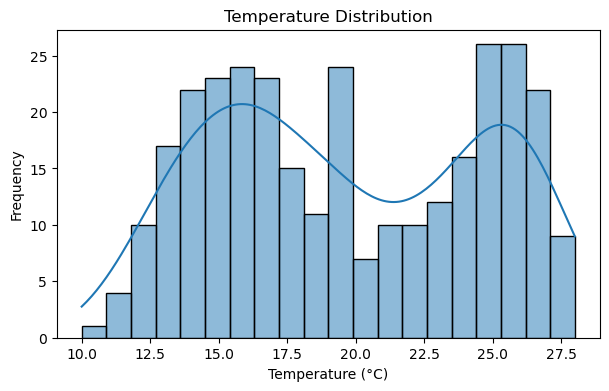

In [84]:
plt.figure(figsize=(7,4))
sns.histplot(df["temperature"], bins=20, kde=True)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()


# AQI Distribution

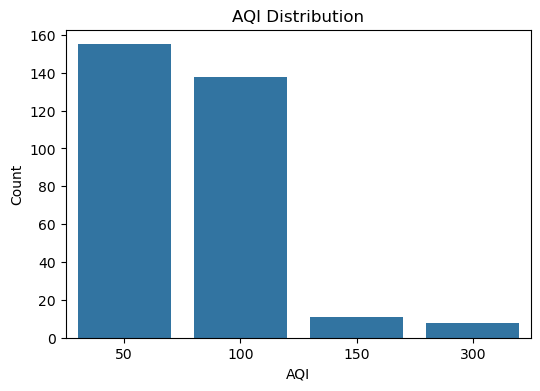

In [85]:
plt.figure(figsize=(6,4))
sns.countplot(x="air_quality_index", data=df)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Count")
plt.show()


# Temperature vs AQI Relationship

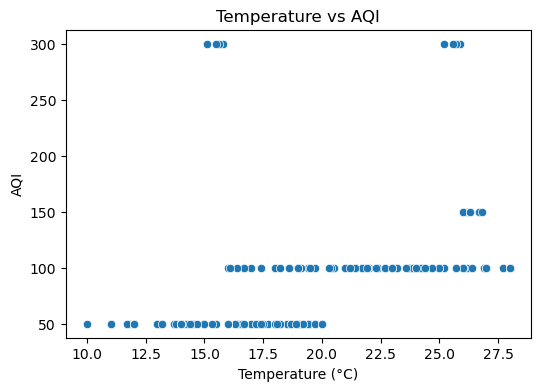

In [86]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="temperature",
    y="air_quality_index",
    data=df
)
plt.title("Temperature vs AQI")
plt.xlabel("Temperature (°C)")
plt.ylabel("AQI")
plt.show()


# Time-based Analysis (Hourly Trend)

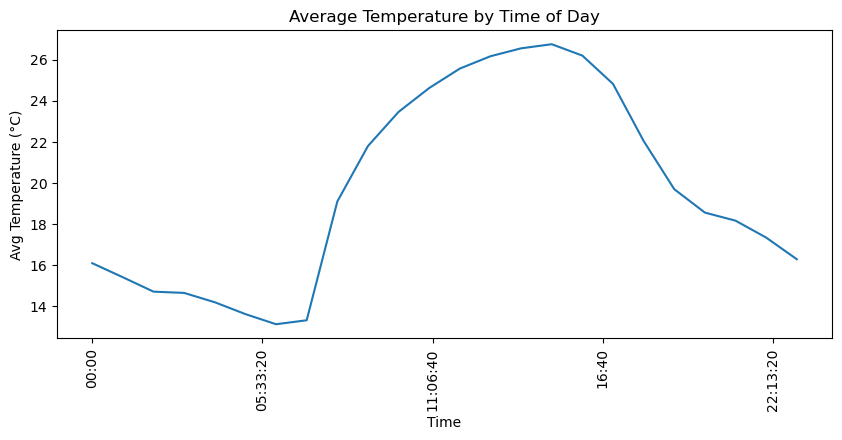

In [87]:
avg_temp_by_time = df.groupby("time")["temperature"].mean()

plt.figure(figsize=(10,4))
avg_temp_by_time.plot()
plt.title("Average Temperature by Time of Day")
plt.xlabel("Time")
plt.ylabel("Avg Temperature (°C)")
plt.xticks(rotation=90)
plt.show()


# data Feature Extracting 

In [88]:
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.weekday  # Monday=0

df.head()


,city,date,time,temperature,air_quality_index,hour,day,month,weekday
0,Hyderabad,2025-12-15,00:00:00,16.0,50,0,15,12,0
1,Hyderabad,2025-12-15,01:00:00,17.0,50,1,15,12,0
2,Hyderabad,2025-12-15,02:00:00,15.0,50,2,15,12,0
3,Hyderabad,2025-12-15,03:00:00,15.0,50,3,15,12,0
4,Hyderabad,2025-12-15,04:00:00,15.0,50,4,15,12,0


In [89]:
numeric_df = df[
    ["temperature", "air_quality_index", "hour", "day", "month", "weekday"]
]
numeric_df.head()


,temperature,air_quality_index,hour,day,month,weekday
0,16.0,50,0,15,12,0
1,17.0,50,1,15,12,0
2,15.0,50,2,15,12,0
3,15.0,50,3,15,12,0
4,15.0,50,4,15,12,0


In [90]:
corr = numeric_df.corr()
corr


,temperature,air_quality_index,hour,day,month,weekday
temperature,1.000000,0.527305,4.308413e-01,-3.530154e-02,NaN,-5.616405e-02
air_quality_index,0.527305,1.000000,1.694150e-01,3.400167e-01,NaN,2.036425e-01
hour,0.430841,0.169415,1.000000e+00,2.391648e-16,NaN,-3.486321e-18
day,-0.035302,0.340017,2.391648e-16,1.000000e+00,NaN,3.812464e-01
month,NaN,NaN,NaN,NaN,NaN,NaN
weekday,-0.056164,0.203642,-3.486321e-18,3.812464e-01,NaN,1.000000e+00


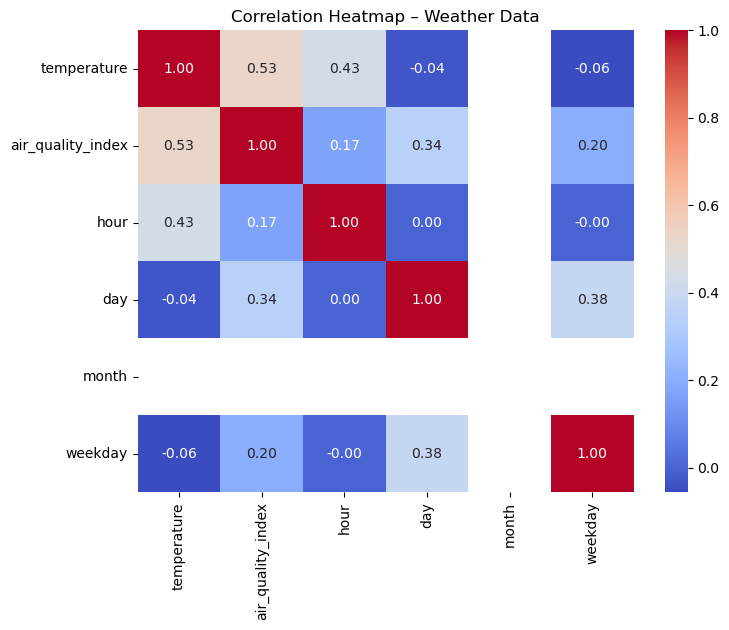

In [91]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap – Weather Data")
plt.show()


In [92]:
df.dtypes

city                         object
date                 datetime64[ns]
time                         object
temperature                 float64
air_quality_index             int64
hour                          int64
day                           int32
month                         int32
weekday                       int32
dtype: object

In [93]:
df

,city,date,time,temperature,air_quality_index,hour,day,month,weekday
0,Hyderabad,2025-12-15,00:00:00,16.0,50,0,15,12,0
1,Hyderabad,2025-12-15,01:00:00,17.0,50,1,15,12,0
2,Hyderabad,2025-12-15,02:00:00,15.0,50,2,15,12,0
3,Hyderabad,2025-12-15,03:00:00,15.0,50,3,15,12,0
4,Hyderabad,2025-12-15,04:00:00,15.0,50,4,15,12,0
...,...,...,...,...,...,...,...,...,...
307,Hyderabad,2025-12-27,19:00:00,21.2,100,19,27,12,5
308,Hyderabad,2025-12-27,20:00:00,20.3,100,20,27,12,5
309,Hyderabad,2025-12-27,21:00:00,19.5,100,21,27,12,5
310,Hyderabad,2025-12-27,22:00:00,19.0,100,22,27,12,5


# Split the dataset

In [94]:
X = df[["hour", "day", "weekday"]]
y = df["temperature"]

print(X.shape)
print(y.shape)



(312, 3)
(312,)


# Train–Test Split

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% test data
    random_state=42     # same result every time
)


In [96]:
print(X_train.shape)

(249, 3)


In [97]:
print(X_test.shape)

(63, 3)


In [98]:
print(y_train.shape)


(249,)


In [99]:
print(y_test.shape)


(63,)


# Linear REGRESSION 

In [100]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [101]:
# Model create & train

In [102]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
# Prediction on test data

In [104]:
y_pred = lr_model.predict(X_test)
y_pred

array([19.97643917, 19.35525357, 19.18742728, 20.12390159, 16.7740756 ,
       21.06037589, 22.84941136, 21.70505597, 22.38979084, 23.32939576,
       17.23056552, 22.28551382, 18.58347495, 19.95607529, 17.95915874,
       17.22743491, 18.10662116, 20.91291348, 22.59767193, 18.47606732,
       16.60624931, 22.53412266, 17.16701625, 16.770945  , 17.54272362,
       23.30590128, 17.29098418, 19.27134042, 20.12077098, 16.91527681,
       23.4101783 , 17.48230495, 19.41567224, 23.24235201, 19.58036792,
       17.8752456 , 23.01723765, 21.85251839, 17.64700064, 16.66666798,
       22.08076335, 16.4619175 , 20.14426546, 17.37489733, 21.62114283,
       22.70194895, 20.20468413, 18.73093736, 16.29096061, 17.85488172,
       22.45334011, 16.14662879, 18.70744289, 20.03998844, 17.68705543,
       20.10040711, 20.76858167, 22.86977524, 17.5630875 , 22.24545903,
       19.03996486, 20.2682334 , 21.82902391])

In [105]:
y_test

228    25.0
9      21.9
57     22.7
60     26.0
25     16.0
       ... 
196    13.0
211    19.2
225    22.7
109    26.9
114    22.0
Name: temperature, Length: 63, dtype: float64

In [106]:
y_train

111    26.9
208    26.0
145    12.0
203    25.0
78     15.0
       ... 
188    18.0
71     17.0
106    23.9
270    12.0
102    14.0
Name: temperature, Length: 249, dtype: float64

In [107]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)


Mean Squared Error (MSE): 19.87672816183632
Root Mean Squared Error (RMSE): 4.458332441825791


In [108]:
comparison = {
    "Actual": y_test.values[:5],
    "Predicted": y_pred[:5]
}

comparison


{'Actual': array([25. , 21.9, 22.7, 26. , 16. ]),
 'Predicted': array([19.97643917, 19.35525357, 19.18742728, 20.12390159, 16.7740756 ])}

# Random Forest Regressor 

In [109]:
from sklearn.ensemble import RandomForestRegressor


In [110]:
rf_model = RandomForestRegressor(
    n_estimators=200,      # number of trees
    random_state=42,
    max_depth=None,        # let trees grow fully
    n_jobs=-1              # use all cores
)


In [111]:
rf_model.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [112]:
y_pred_rf = rf_model.predict(X_test)
y_pred_rf

array([25.6855, 22.5095, 22.5065, 26.3275, 16.3365, 27.9495, 17.9215,
       25.097 , 18.595 , 17.4905, 15.68  , 18.567 , 13.562 , 25.885 ,
       14.013 , 14.655 , 14.4945, 26.466 , 17.494 , 19.1815, 16.15  ,
       19.3095, 13.785 , 14.5715, 15.184 , 15.0235, 11.944 , 22.5   ,
       25.4455, 15.021 , 16.724 , 15.311 , 23.8685, 17.52  , 24.866 ,
       13.5945, 18.8835, 24.994 , 14.9055, 12.542 , 21.3665, 16.31  ,
       25.6065, 13.6555, 25.367 , 18.126 , 25.6475, 13.37  , 15.4535,
       14.842 , 19.379 , 15.98  , 19.6895, 26.5265, 12.9175, 25.0865,
       26.3905, 17.2625, 13.802 , 19.232 , 22.3715, 26.6   , 21.8335])

In [113]:
y_test

228    25.0
9      21.9
57     22.7
60     26.0
25     16.0
       ... 
196    13.0
211    19.2
225    22.7
109    26.9
114    22.0
Name: temperature, Length: 63, dtype: float64

In [131]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest MSE:", mse_rf*100)
print("Random Forest RMSE:", rmse_rf*10)


Random Forest MSE: 90.42212499999835
Random Forest RMSE: 9.509054895203747


In [115]:
for actual, pred in zip(y_test.values[:5], y_pred_rf[:5]):
    print(f"Actual: {actual:.1f}  |  Predicted: {pred:.1f}")


Actual: 25.0  |  Predicted: 25.7
Actual: 21.9  |  Predicted: 22.5
Actual: 22.7  |  Predicted: 22.5
Actual: 26.0  |  Predicted: 26.3
Actual: 16.0  |  Predicted: 16.3


In [150]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest MSE:", mse_rf*100)
print("Random Forest RMSE:", rmse_rf*10)


Random Forest MSE: 90.42212499999835
Random Forest RMSE: 9.509054895203747


# XGBOOST

In [116]:
from xgboost import XGBRegressor


In [117]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)


In [118]:
xgb_model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [120]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb


array([25.504953, 22.297146, 22.574783, 26.37536 , 16.49776 , 27.775404,
       17.765957, 24.836689, 18.23657 , 18.00913 , 16.391127, 17.911129,
       13.745566, 25.77847 , 14.107405, 15.46466 , 14.63283 , 26.625307,
       17.280981, 18.919304, 16.356245, 19.136475, 13.558909, 14.320881,
       16.51756 , 14.577714, 11.708253, 22.356405, 25.348703, 15.545838,
       17.169481, 15.647622, 24.449823, 17.163506, 24.531403, 13.477572,
       19.067316, 24.496033, 14.71582 , 12.164998, 21.704454, 16.705875,
       25.561634, 13.431407, 25.011957, 17.810305, 25.845182, 13.558852,
       15.921822, 15.536079, 19.749105, 15.858773, 19.787722, 26.768154,
       12.530072, 24.926836, 26.60383 , 17.282318, 13.925621, 19.504185,
       22.275211, 26.501503, 21.742071], dtype=float32)

In [126]:
y_test

228    25.0
9      21.9
57     22.7
60     26.0
25     16.0
       ... 
196    13.0
211    19.2
225    22.7
109    26.9
114    22.0
Name: temperature, Length: 63, dtype: float64

In [130]:
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print("XGBoost MSE:", mse_xgb*100)
print("XGBoost RMSE:", rmse_xgb*10)


XGBoost MSE: 78.08389124248573
XGBoost RMSE: 8.836508996344978


In [127]:
for actual, pred in zip(y_test.values[:5], y_pred_xgb[:5]):
    print(f"Actual: {actual:.1f} | Predicted: {pred:.1f}")


Actual: 25.0 | Predicted: 25.5
Actual: 21.9 | Predicted: 22.3
Actual: 22.7 | Predicted: 22.6
Actual: 26.0 | Predicted: 26.4
Actual: 16.0 | Predicted: 16.5


# Decision Tree

In [132]:
from sklearn.tree import DecisionTreeRegressor


In [133]:
dt_model = DecisionTreeRegressor(
    max_depth=5,        # tree ko control karta hai
    random_state=42
)


In [134]:
dt_model.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [136]:
y_pred_dt = dt_model.predict(X_test)
y_pred_dt

array([26.05714286, 21.975     , 21.975     , 26.05714286, 15.63636364,
       26.05714286, 18.47142857, 26.05714286, 18.47142857, 16.76923077,
       15.63636364, 18.47142857, 12.72857143, 26.05714286, 12.72857143,
       14.625     , 14.66666667, 26.05714286, 18.47142857, 19.3       ,
       15.63636364, 19.66666667, 14.625     , 14.625     , 15.63636364,
       15.33333333, 12.        , 21.975     , 26.05714286, 14.625     ,
       17.46666667, 15.63636364, 24.04583333, 18.6       , 24.04583333,
       12.72857143, 18.47142857, 26.05714286, 14.625     , 12.        ,
       20.95      , 16.        , 26.05714286, 14.625     , 26.05714286,
       18.47142857, 26.05714286, 13.85555556, 14.625     , 14.66666667,
       18.47142857, 16.16666667, 19.65714286, 26.05714286, 12.72857143,
       26.05714286, 26.05714286, 18.47142857, 14.625     , 19.53      ,
       21.975     , 26.05714286, 22.33333333])

In [137]:
y_test

228    25.0
9      21.9
57     22.7
60     26.0
25     16.0
       ... 
196    13.0
211    19.2
225    22.7
109    26.9
114    22.0
Name: temperature, Length: 63, dtype: float64

In [152]:
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)

print("Decision Tree MSE:", mse_dt)
print("Decision Tree RMSE:", rmse_dt)


Decision Tree MSE: 1.4447350084650348
Decision Tree RMSE: 1.2019713010155586


In [139]:
for actual, pred in zip(y_test.values[:5], y_pred_dt[:5]):
    print(f"Actual: {actual:.1f} | Predicted: {pred:.1f}")


Actual: 25.0 | Predicted: 26.1
Actual: 21.9 | Predicted: 22.0
Actual: 22.7 | Predicted: 22.0
Actual: 26.0 | Predicted: 26.1
Actual: 16.0 | Predicted: 15.6


# LSTM

In [141]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

C:\Users\SNEHA\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [142]:
# Sort by time (VERY IMPORTANT)
df_lstm = df.sort_values(["date", "hour"])

temperature_values = df_lstm["temperature"].values.reshape(-1, 1)


In [143]:
scaler = MinMaxScaler()
temp_scaled = scaler.fit_transform(temperature_values)


In [144]:
def create_sequences(data, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(temp_scaled, window_size=24)

print(X_lstm.shape, y_lstm.shape)


(288, 24, 1) (288, 1)


In [145]:
split = int(0.8 * len(X_lstm))

X_train_lstm = X_lstm[:split]
X_test_lstm = X_lstm[split:]

y_train_lstm = y_lstm[:split]
y_test_lstm = y_lstm[split:]


In [146]:
model = Sequential()
model.add(LSTM(50, activation="relu", input_shape=(24, 1)))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()


C:\Users\SNEHA\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [148]:
history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0081 - val_loss: 0.0059
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0090 - val_loss: 0.0062
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0082 - val_loss: 0.0060
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0082 - val_loss: 0.0061
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0083 - val_loss: 0.0065
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0092 - val_loss: 0.0060
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0112 - val_loss: 0.0100
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0101 - val_loss: 0.0061
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0076 - val_loss: 0.0061
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0079 - val_loss: 0.0053
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0081 - val_loss: 0.0058
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0

In [160]:
y_pred_lstm = model.predict(X_test_lstm)

# Inverse scaling
y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm)
y_test_lstm_inv = scaler.inverse_transform(y_test_lstm)

rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_inv, y_pred_lstm_inv))
print("LSTM RMSE:", rmse_lstm*10)

mse_lstm = mean_squared_error(y_pred_lstm_inv, y_test_lstm_inv)
print("LSTM MSE:",mse_lstm*100)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
LSTM RMSE: 8.88712351845526
LSTM MSE: 78.9809644322806


In [164]:
import pandas as pd
import numpy as np

# Create results dataframe
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor",
        "XGBoost Regressor",
        "Decision Tree Regressor",
        "LSTM"
    ],
    "MSE": [
        19.87672816183632,
        90.42212499999835,
        78.08389124248573,
        1.4447350084650348,
        78.9809644322806   # LSTM ka MSE nahi calculate kiya
    ],
    "RMSE": [
        4.458332441825791,
        9.509054895203747,
        8.836508996344978,
        1.2019713010155586,
        8.88712351845526
    ]
})


results




,Model,MSE,RMSE
0,Linear Regression,19.876728,4.458332
1,Random Forest Regressor,90.422125,9.509055
2,XGBoost Regressor,78.083891,8.836509
3,Decision Tree Regressor,1.444735,1.201971
4,LSTM,78.980964,8.887124


In [165]:
import joblib

# model save
joblib.dump(rf_model, "random_forest_model.pkl")

print("Model saved as random_forest_model.pkl")


Model saved as random_forest_model.pkl


In [166]:
import joblib

# model load
loaded_model = joblib.load("random_forest_model.pkl")

print("Model loaded successfully")


Model loaded successfully


In [167]:
# sample prediction
pred = loaded_model.predict(X_test[:5])
print(pred)


[25.6855 22.5095 22.5065 26.3275 16.3365]
